In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set style untuk seaborn
sns.set_theme(style="whitegrid")

ModuleNotFoundError: No module named 'pandas'

## 1. Visualisasi Dataset
Melihat distribusi kelas `stress_level` dan hubungan antara `bpm` dan `skin_temp`.

C:\Users\Zann\AppData\Local\Temp\ipykernel_29344\137427913.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="stress_level", order=["Low", "Medium", "High"], palette="viridis")


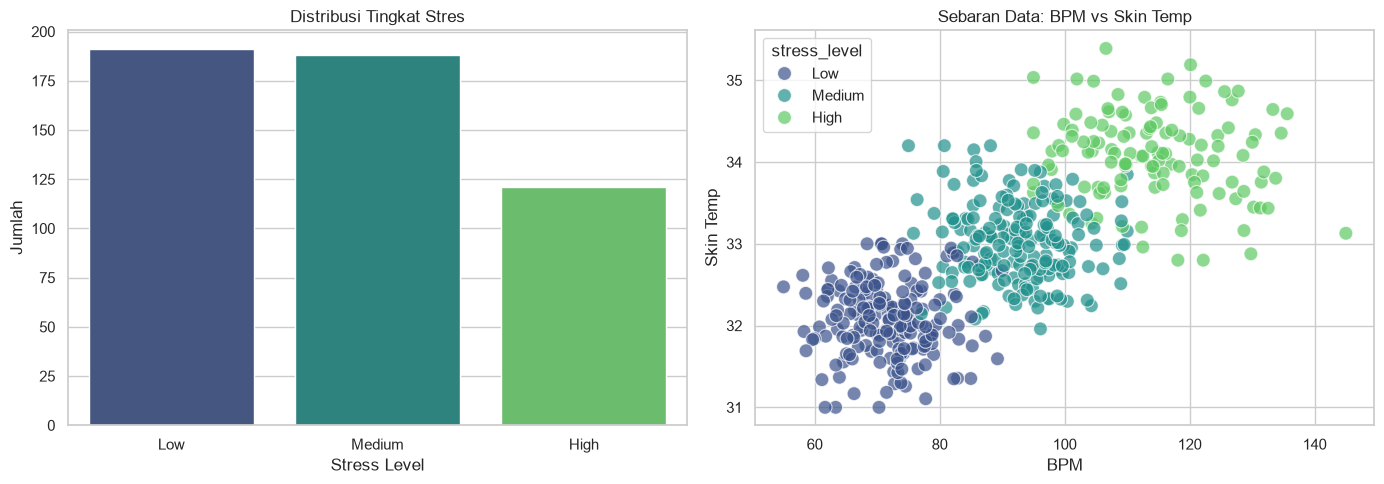

In [2]:
# Load data
df = pd.read_csv("stress_dataset_large.csv")

plt.figure(figsize=(14, 5))

# Bar chart Distribusi
plt.subplot(1, 2, 1)
sns.countplot(data=df, x="stress_level", order=["Low", "Medium", "High"], palette="viridis")
plt.title("Distribusi Tingkat Stres")
plt.xlabel("Stress Level")
plt.ylabel("Jumlah")

# Scatter plot Fitur
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x="bpm", y="skin_temp", hue="stress_level", hue_order=["Low", "Medium", "High"], palette="viridis", s=100, alpha=0.7)
plt.title("Sebaran Data: BPM vs Skin Temp")
plt.xlabel("BPM")
plt.ylabel("Skin Temp")

plt.tight_layout()
plt.show()

## 2. Pelatihan Model dan Evaluasi
Melatih ulang model Random Forest dan melihat performanya menggunakan **Confusion Matrix**.

Accuracy: 0.88

Classification Report:
               precision    recall  f1-score   support

         Low       0.90      0.97      0.94        38
      Medium       0.84      0.84      0.84        38
        High       0.90      0.79      0.84        24

    accuracy                           0.88       100
   macro avg       0.88      0.87      0.87       100
weighted avg       0.88      0.88      0.88       100



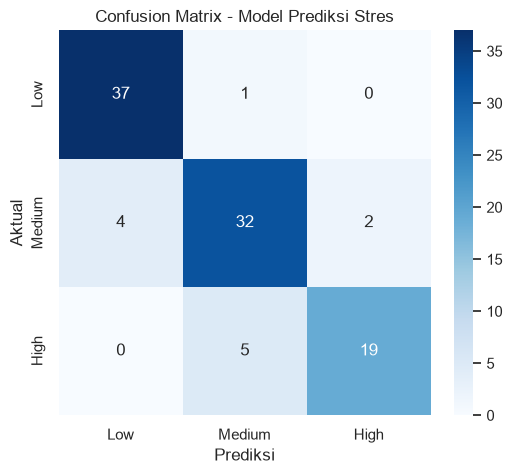

In [3]:
# Preprocessing data
label_map = {"Low": 0, "Medium": 1, "High": 2}
df["stress_level_encoded"] = df["stress_level"].map(label_map)

X = df[["bpm", "skin_temp"]]
y = df["stress_level_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pelatihan Model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Prediksi dan Evaluasi
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred, target_names=["Low", "Medium", "High"]))

# Membuat Confusion Matrix
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.title("Confusion Matrix - Model Prediksi Stres")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()